# Feature Extraction
Select features via correlation and LightGBM importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('preprocessed.csv')
print(df.shape)
df.head(2)

(746906, 17)


,manufacturer,mileage,transmission,drivetrain,fuel_type,mpg,accidents_or_damage,one_owner,personal_use_only,seller_rating,driver_rating,driver_reviews_num,price_drop,price,engine_displacement,engine_hp,car_age
0,0,92945.0,845,26,17,38.5,0.0,0.0,0.0,4.5,4.4,12.0,300.0,13988.0,1.5,90.0,11
1,0,47645.0,862,26,20,38.5,1.0,1.0,1.0,4.5,4.4,12.0,627.0,17995.0,1.5,260.0,11


In [3]:
corr = df.corr()['price'].drop('price').abs().sort_values(ascending=False)
print(corr.to_string())

mileage                0.538187
car_age                0.373765
engine_displacement    0.372198
driver_reviews_num     0.328470
mpg                    0.280895
one_owner              0.250529
accidents_or_damage    0.208825
price_drop             0.183687
fuel_type              0.173014
transmission           0.119410
drivetrain             0.117962
engine_hp              0.113415
seller_rating          0.072325
driver_rating          0.042481
manufacturer           0.020031
personal_use_only      0.009256


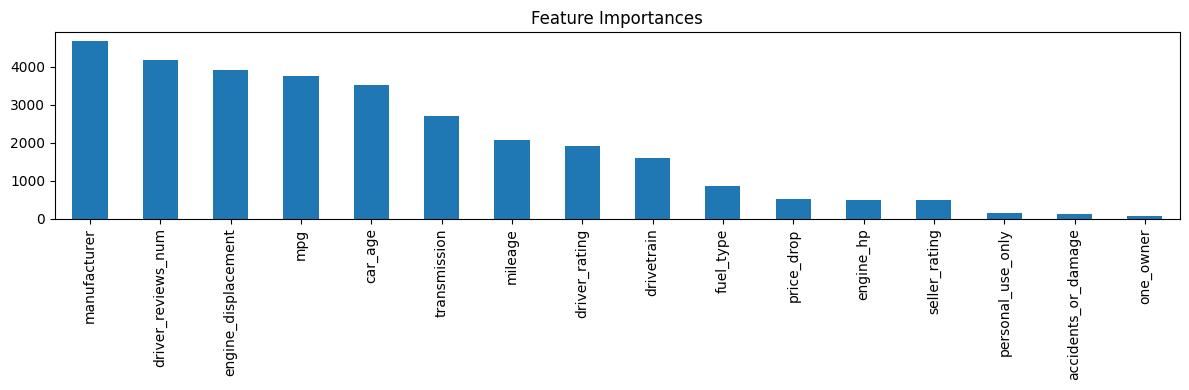

In [4]:
X, y = df.drop(columns=['price']), np.log1p(df['price'])
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

lgb_selector = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    random_state=42, n_jobs=-1, verbosity=-1
)
lgb_selector.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
)

importances = pd.Series(lgb_selector.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(12, 4), title='Feature Importances')
plt.tight_layout()
plt.show()

In [5]:
top_features = importances[importances > importances.mean()].index.tolist()
print(f'Selected {len(top_features)} features: {top_features}')

Selected 7 features: ['manufacturer', 'driver_reviews_num', 'engine_displacement', 'mpg', 'car_age', 'transmission', 'mileage']


In [6]:
reg_df = df[top_features + ['price']]
reg_df.to_csv('regression_features.csv', index=False)
print(f'Saved regression_features.csv: {reg_df.shape}')

Saved regression_features.csv: (746906, 8)


In [7]:
q33 = df['price'].quantile(1/3)
q67 = df['price'].quantile(2/3)
df['price_category'] = pd.cut(
    df['price'],
    bins=[-np.inf, q33, q67, np.inf],
    labels=[0, 1, 2]
).astype(int)

print(df['price_category'].value_counts().sort_index())
print(f'Thresholds — cheap < {q33:.0f}, medium < {q67:.0f}, expensive >= {q67:.0f}')

clf_df = df[top_features + ['price_category']]
clf_df.to_csv('classification_features.csv', index=False)
print(f'Saved classification_features.csv: {clf_df.shape}')

price_category
0    248969
1    249038
2    248899
Name: count, dtype: int64
Thresholds — cheap < 22385, medium < 34899, expensive >= 34899
Saved classification_features.csv: (746906, 8)
